# Phase 4: Anomaly & Outlier Detection
**Dataset**: Lending Club (accepted loans, 2.26 juta record, 12 fitur final) · **Owner**: Data Engineer & Pattern Analyst

## Tujuan
Mengidentifikasi record yang menyimpang signifikan dari data lainnya, lalu menentukan apakah tiap penyimpangan merupakan **data error**, **rare case** (kasus valid tak biasa), atau **risk signal** (sinyal yang perlu dieskalasi).

## Cakupan notebook
| Komponen | Implementasi |
|---|---|
| Metode deteksi: IQR, Z-score, Isolation Forest, dibandingkan sistematis | Bagian 2-4 + tabel per-fitur + tier corroboration (Bagian 5). Mahalanobis ditambahkan sebagai metode multivariat pendukung. |
| Cross-reference dengan outlier cluster Fase 2 | Bagian 5: noise DBSCAN (Phase 2) disilangkan dengan flag statistik/IF. |
| Interpretasi bisnis: tiap anomali diklasifikasi data error / rare case / risk signal dengan bukti | Bagian 6-6c + narasi Bagian 9. |

## Prinsip metodologis (anti-circularity)
`risk_signal` **tidak** didefinisikan dari `loan_status` (outcome). Melabeli anomali sebagai berisiko karena ia gagal bayar, lalu menyimpulkan anomali = risiko, adalah tautologi. Sebagai gantinya, sinyal risiko dinilai **independen** dari atribut pra-pinjaman (Bagian 6b), lalu **divalidasi** terhadap outcome, sehingga klaimnya dibuktikan, bukan diasumsikan.

> **Catatan data**: memakai `cleaned_lending_club_no_winsorization.csv` (nilai asli). Winsorization meng-cap ekor distribusi sehingga justru menghapus anomali, tidak boleh dipakai di fase ini.

In [2]:
import os
# Pindah ke root proyek agar path data konsisten di mana pun notebook dijalankan
for _ in range(6):
    if os.path.isdir('data'): break
    os.chdir('..')
print('working dir:', os.path.basename(os.getcwd()))

working dir: lending-club-loans


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

RANDOM_SEED = 42
IQR_MULT   = 3.0     # 3x IQR = outlier ekstrem (1.5x terlalu longgar untuk data masif)
Z_THRESH   = 3.0     # |z| > 3 = di luar 99.7% distribusi normal
MAHA_PCTL  = 0.999   # persentil chi-square untuk ambang Mahalanobis
IF_CONTAM  = 0.01    # Isolation Forest: asumsi ~1% anomali
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 30)

## 1. Load data (non-winsorized = nilai asli)
Tiga input: fitur bersih non-winsorized, referensi `loan_status` (label outcome, hanya untuk validasi), dan label noise DBSCAN dari Phase 2 (untuk cross-reference).

In [4]:
df   = pd.read_csv('data/processed/cleaned_lending_club_no_winsorization.csv')
loan = pd.read_csv('data/processed/loan_status_reference.csv')['loan_status']
dbs  = pd.read_csv('data/processed/phase2_dbscan_labels.csv')   # orig_index, dbscan_label, is_noise
assert len(df) == len(loan), 'baris tidak selaras'
print(f'df: {df.shape} | loan_status: {len(loan):,} | dbscan sample: {len(dbs):,}')

feats = [c for c in df.columns if c != 'grade']   # grade ordinal, minim outlier
X  = df[feats].values.astype(float)
Xz = StandardScaler().fit_transform(X)            # standar untuk Mahalanobis & IsoForest
print('fitur deteksi:', feats)

df: (2260668, 12) | loan_status: 2,260,668 | dbscan sample: 100,000
fitur deteksi: ['annual_inc', 'dti', 'fico_range_low', 'revol_util', 'emp_length', 'loan_amnt', 'term', 'bc_open_to_buy', 'total_bc_limit', 'all_util', 'inq_last_6mths']


## 2. Metode statistik univariat: IQR (3×) & Z-score (|z|>3)
Menandai **point outlier**: nilai ekstrem pada satu dimensi. IQR (berbasis kuartil) robust terhadap distribusi miring; Z-score mengasumsikan normalitas. Keduanya di-OR per fitur, lalu digabung antar-fitur. Tabel per-fitur memperlihatkan dari mana anomali berasal.

In [5]:
iqr_flag = np.zeros(len(df), dtype=bool)
z_flag   = np.zeros(len(df), dtype=bool)
rows = []
for j, c in enumerate(feats):
    col = X[:, j]
    q1, q3 = np.percentile(col, [25, 75]); iqr = q3 - q1
    lo, hi = q1 - IQR_MULT*iqr, q3 + IQR_MULT*iqr
    fi = (col < lo) | (col > hi)
    std = col.std()
    fz = (np.abs((col - col.mean())/std) > Z_THRESH) if std > 0 else np.zeros(len(col), bool)
    iqr_flag |= fi; z_flag |= fz
    rows.append((c, int(fi.sum()), int(fz.sum())))
print(pd.DataFrame(rows, columns=['fitur','IQR>3x','|z|>3']).to_string(index=False))
print(f'\nbaris ter-flag IQR: {iqr_flag.sum():,} | Z-score: {z_flag.sum():,}')

         fitur  IQR>3x  |z|>3
    annual_inc   36551   6313
           dti    7538   7836
fico_range_low    1013  31048
    revol_util       7    131
    emp_length       0      0
     loan_amnt       0      0
          term       0      0
bc_open_to_buy   80119  48854
total_bc_limit   39297  43548
      all_util  124565  26498
inq_last_6mths    7925  25305

baris ter-flag IQR: 236,492 | Z-score: 143,542


## 3. Metode multivariat: jarak Mahalanobis (χ² 99.9%)
IQR/Z-score buta terhadap kombinasi antar-fitur. Mahalanobis mengukur jarak sebuah titik dari centroid dengan memperhitungkan kovarians, sehingga menangkap **contextual outlier** (tiap dimensi normal, tapi kombinasinya janggal). Ambang = kuantil χ² 99.9% dengan derajat bebas = jumlah fitur.

In [6]:
mu   = Xz.mean(axis=0)
inv  = np.linalg.pinv(np.cov(Xz, rowvar=False))
diff = Xz - mu
md2  = np.einsum('ij,jk,ik->i', diff, inv, diff)   # jarak Mahalanobis kuadrat
thr  = chi2.ppf(MAHA_PCTL, df=len(feats))
maha_flag = md2 > thr
print(f'ambang chi2({len(feats)}, {MAHA_PCTL}) = {thr:.1f} | ter-flag: {maha_flag.sum():,}')

ambang chi2(11, 0.999) = 31.3 | ter-flag: 47,104


## 4. Isolation Forest: deteksi anomali struktural
Metode berbasis ensemble: titik yang mudah diisolasi oleh partisi acak dianggap anomali. Tidak mengasumsikan bentuk distribusi, dan menangkap anomali struktural yang lolos dari uji statistik.

**Pemilihan `contamination`:** parameter ini menentukan proporsi baris yang ditandai dan tidak punya nilai "benar" yang diketahui. Alternatif data-driven, mencari **gap** (jurang) terbesar pada kurva skor anomali terurut, diuji secara empiris di Bagian 4b: pada data ini kurvanya mulus (khas fitur finansial heavy-tailed) sehingga lokasi gap tidak stabil dan jatuh di ekor ekstrem (~0,1% populasi), terlalu ketat untuk berperan sebagai satu dari empat metode corroboration. Karena itu dipakai `contamination=1%` sebagai juri terketat di antara keempat metode, dan uji sensitivitas 4b menunjukkan hasil akhir (anomali terkonfirmasi ≥2 metode) hampir tidak berubah antara cutoff gap dan 1% (115.195 vs 116.225; selisih <1%).

In [7]:
iso = IsolationForest(contamination=IF_CONTAM, random_state=RANDOM_SEED, n_jobs=-1)
if_flag = iso.fit_predict(Xz) == -1
print(f'ter-flag Isolation Forest: {if_flag.sum():,}')

ter-flag Isolation Forest: 22,607


### 4b. Uji ambang data-driven (metode gap) & sensitivitas cutoff

Metode gap: urutkan skor anomali menurun, cari selisih (gap) terbesar antar skor berurutan, jadikan titik itu cutoff alami. Tiga hal diuji: (1) di mana gap terbesar jatuh, (2) apakah lokasinya stabil terhadap window pencarian, (3) seberapa sensitif jumlah anomali terkonfirmasi (≥2 metode) terhadap pilihan cutoff IF.

Gap terbesar pada kurva skor terurut: rank 2,271 (0.100% populasi), besar gap 0.0000691 (median gap antar-skor: 0.000000512)
Stabilitas lokasi gap terhadap window pencarian:
  window 0.02%-3%: cut di rank 687 (0.030%)
  window 0.10%-5%: cut di rank 2,271 (0.100%)
  window 0.05%-10%: cut di rank 2,271 (0.100%)

Sensitivitas konsensus (>=2 metode) terhadap pilihan cutoff IF:
  IF @ gap (0.100%)               : IF flag    2,271 -> terkonfirmasi: 115,195
  IF @ contamination 1% (dipakai) : IF flag   22,607 -> terkonfirmasi: 116,225
  IF @ contamination 5%           : IF flag  113,033 -> terkonfirmasi: 139,946


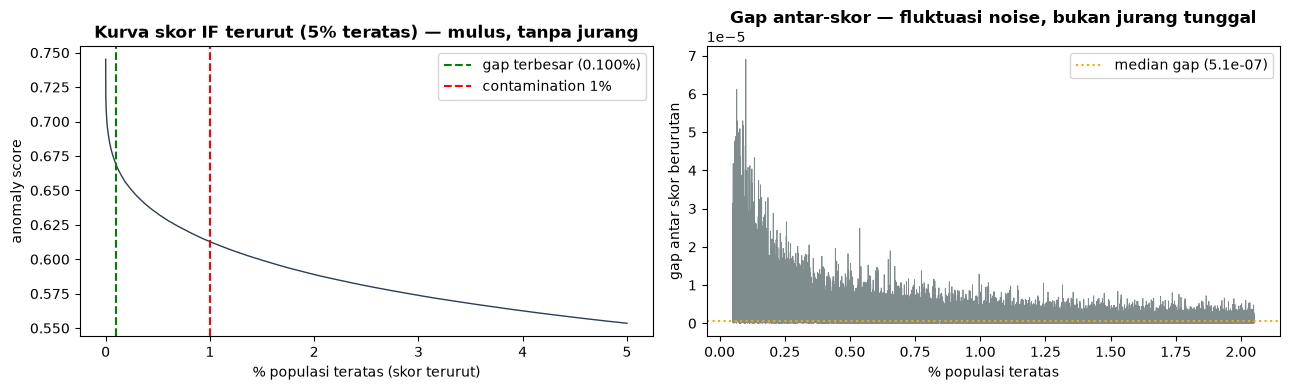

In [8]:
# Skor anomali kontinu dari model iso yang sama: contamination hanya menggeser ambang
# predict, tidak mengubah score_samples. Dihitung per-chunk agar hemat memori.
CH = 250_000
scores = np.concatenate([-iso.score_samples(Xz[i:i+CH]) for i in range(0, len(Xz), CH)])

s = np.sort(scores)[::-1]; n = len(s)
lo, hi = int(n*0.0005), int(n*0.05)          # cari gap di wilayah ekor 0.05%-5%
gaps = s[lo:hi-1] - s[lo+1:hi]
k = int(np.argmax(gaps)) + lo + 1
print(f"Gap terbesar pada kurva skor terurut: rank {k:,} ({k/n*100:.3f}% populasi), "
      f"besar gap {gaps.max():.7f} (median gap antar-skor: {np.median(gaps):.9f})")
print("Stabilitas lokasi gap terhadap window pencarian:")
for a, b in [(0.0002, 0.03), (0.001, 0.05), (0.0005, 0.10)]:
    lo2, hi2 = int(n*a), int(n*b)
    g2 = s[lo2:hi2-1] - s[lo2+1:hi2]
    k2 = int(np.argmax(g2)) + lo2 + 1
    print(f"  window {a*100:.2f}%-{b*100:.0f}%: cut di rank {k2:,} ({k2/n*100:.3f}%)")

# Sensitivitas: jumlah anomali terkonfirmasi (>=2 metode) bila cutoff IF diganti
base = iqr_flag.astype(int) + z_flag.astype(int) + maha_flag.astype(int)
def cons(mask): return int(((base + mask) >= 2).sum())
print("\nSensitivitas konsensus (>=2 metode) terhadap pilihan cutoff IF:")
for label, mask in [
    (f"IF @ gap ({k/n*100:.3f}%)", scores >= s[k-1]),
    ("IF @ contamination 1% (dipakai)", if_flag),
    ("IF @ contamination 5%", scores >= s[int(n*0.05)-1]),
]:
    print(f"  {label:32s}: IF flag {int(mask.sum()):>8,} -> terkonfirmasi: {cons(mask):,}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
top5 = s[:int(n*0.05)]
ax[0].plot(np.arange(1, len(top5)+1)/n*100, top5, color='#2c3e50', lw=1)
ax[0].axvline(k/n*100, color='green', ls='--', label=f'gap terbesar ({k/n*100:.3f}%)')
ax[0].axvline(1.0, color='red', ls='--', label='contamination 1%')
ax[0].set_xlabel('% populasi teratas (skor terurut)'); ax[0].set_ylabel('anomaly score')
ax[0].set_title('Kurva skor IF terurut (5% teratas) — mulus, tanpa jurang', fontweight='bold')
ax[0].legend()
win = gaps[:int(n*0.02)]
ax[1].plot(np.arange(lo+1, lo+1+len(win))/n*100, win, color='#7f8c8d', lw=0.6)
ax[1].axhline(np.median(gaps), color='orange', ls=':', label=f'median gap ({np.median(gaps):.1e})')
ax[1].set_xlabel('% populasi teratas'); ax[1].set_ylabel('gap antar skor berurutan')
ax[1].set_title('Gap antar-skor — fluktuasi noise, bukan jurang tunggal', fontweight='bold')
ax[1].legend()
plt.tight_layout(); plt.show()

**Kesimpulan 4b.** (1) Gap terbesar jatuh di ekor ekstrem (0,10% populasi ≈ 2.271 baris) dengan besar hanya ~7×10⁻⁵ — kurva skornya mulus, tidak ada jurang tunggal yang tegas. (2) Lokasinya **tidak stabil**: menggeser window pencarian memindahkan cutoff dari rank 687 ke 2.271 (>3×), tanda pemotongan berbasis gap bersifat arbitrary pada data heavy-tailed seperti ini. (3) Yang menentukan hasil akhir bukan cutoff IF melainkan **corroboration ≥2 metode**: cutoff gap vs 1% hanya menggeser jumlah terkonfirmasi <1% (115.195 vs 116.225), sedangkan 5% menggelembungkannya 20% (139.946). `contamination=1%` dipertahankan sebagai juri terketat, dengan konsensus ensemble sebagai jaring pengaman.

## 5. Corroboration (≥2 metode) & cross-reference DBSCAN (Phase 2)
Satu metode saja rawan false positive. Anomali **terkonfirmasi** = ditandai ≥2 metode independen. Lalu disilangkan dengan **noise points DBSCAN** dari Phase 2: jika region kepadatan-rendah yang ditemukan DBSCAN juga ditandai metode statistik/IF, kedua pendekatan saling menguatkan.

In [9]:
flags = pd.DataFrame({'IQR': iqr_flag, 'Zscore': z_flag,
                      'Mahalanobis': maha_flag, 'IsolationForest': if_flag})
n_methods = flags.sum(axis=1)
corroborated = n_methods >= 2
print(f'total kandidat (>=1 metode): {(n_methods>=1).sum():,}')
print(f'terkonfirmasi (>=2 metode) : {corroborated.sum():,}')
print(f'terkonfirmasi (>=3 metode) : {(n_methods>=3).sum():,}')

noise_idx  = dbs.loc[dbs['is_noise'] == 1, 'orig_index'].values
db_nm      = n_methods.values[noise_idx]
print(f'\nDBSCAN noise (n={len(noise_idx)}): juga ter-flag >=1 metode: '
      f'{(db_nm>=1).sum()} ({(db_nm>=1).mean()*100:.0f}%), >=2 metode: {(db_nm>=2).sum()}')

total kandidat (>=1 metode): 271,143
terkonfirmasi (>=2 metode) : 116,225
terkonfirmasi (>=3 metode) : 46,604

DBSCAN noise (n=426): juga ter-flag >=1 metode: 289 (68%), >=2 metode: 204


## 6. Kategori 1: data_error (implausibilitas nilai)
Anomali dengan nilai **mustahil / placeholder**, berdasarkan penalaran domain (bukan outcome):
- `annual_inc > $5.000.000`, peminjam pinjaman konsumen (<$40rb) dengan penghasilan sebesar ini tidak masuk akal (teramati sampai $110 juta → jelas salah entri).
- `dti > 100`, cicilan utang melebihi 100% pendapatan tak berkelanjutan; mencakup **sentinel `dti = 999`** (kode tak-terhitung).

In [10]:
idx_conf = np.where(corroborated.values)[0]
inc = df['annual_inc'].values; dti = df['dti'].values
is_error = (inc[idx_conf] > 5_000_000) | (dti[idx_conf] > 100)
print(f'data_error terdeteksi: {is_error.sum():,}')

data_error terdeteksi: 2,654


## 6b. Kategori 2: risk_signal (penilaian INDEPENDEN + validasi)
Sinyal risiko dinilai dari **skor tekanan kredit** yang dihitung hanya dari atribut pra-pinjaman: `dti + revol_util + all_util + inq_last_6mths` (masing-masing di-z-score lalu dijumlah). Ambang = persentil 90 skor di antara anomali non-error (data-driven, bukan angka sembarang).

Kunci anti-circularity: subset ini dibentuk **tanpa** melihat `loan_status`, lalu **divalidasi** dengan membandingkan tingkat Charged Off/Default-nya terhadap populasi. Jika lebih tinggi, barulah label risk signal dibenarkan oleh bukti.

In [11]:
co_status = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)',
             'Does not meet the credit policy. Status:Charged Off']
is_co = loan.isin(co_status).values
risk_cols = ['dti', 'revol_util', 'all_util', 'inq_last_6mths']
Zrisk = StandardScaler().fit_transform(df[risk_cols].values)
rs_conf = Zrisk.sum(axis=1)[idx_conf]
thr_risk = np.percentile(rs_conf[~is_error], 90)
risk_flag = (~is_error) & (rs_conf >= thr_risk)
print(f'ambang skor (p90 non-error) = {thr_risk:.2f} | risk_signal: {risk_flag.sum():,}')

co_all      = is_co.mean()*100
co_anom     = is_co[idx_conf].mean()*100
co_highrisk = is_co[idx_conf][risk_flag].mean()*100
print(f'\nVALIDASI CO-rate -> populasi: {co_all:.1f}% | semua anomali: {co_anom:.1f}% | risk_signal: {co_highrisk:.1f}%')
print(f'risk_signal {"TERBUKTI" if co_highrisk>co_all else "TIDAK terbukti"} lebih berisiko '
      f'({co_highrisk:.1f}% vs {co_all:.1f}%, lift {co_highrisk/co_all:.2f}x)')

ambang skor (p90 non-error) = 4.39 | risk_signal: 11,358

VALIDASI CO-rate -> populasi: 13.1% | semua anomali: 8.7% | risk_signal: 19.2%
risk_signal TERBUKTI lebih berisiko (19.2% vs 13.1%, lift 1.47x)


## 6c. Klasifikasi final (3 kategori) + tipe outlier
Prioritas: **data_error → risk_signal → rare_case**. `rare_case` = anomali plausibel yang bukan error dan bukan high-stress (mayoritas profil affluent/limit besar).

Tipe outlier (untuk Section 2 report): **point** (ekstrem univariat), **contextual** (hanya janggal secara multivariat), **collective** (bagian region noise DBSCAN).

In [12]:
cls = np.where(is_error, 'data_error', np.where(risk_flag, 'risk_signal', 'rare_case'))
print('Distribusi kategori:')
for k in ['data_error','risk_signal','rare_case']:
    print(f'  {k:12s}: {(cls==k).sum():,}')

is_noise_full = np.zeros(len(df), bool); is_noise_full[noise_idx] = True
uni_flag = iqr_flag | z_flag
otype = np.where(is_noise_full[idx_conf], 'collective',
        np.where(uni_flag[idx_conf], 'point', 'contextual'))
print('\nTipe outlier:', {k:int((otype==k).sum()) for k in ['point','contextual','collective']})

Distribusi kategori:
  data_error  : 2,654
  risk_signal : 11,358
  rare_case   : 102,213

Tipe outlier: {'point': 115978, 'contextual': 43, 'collective': 204}


## 7. Visualisasi & simpan hasil

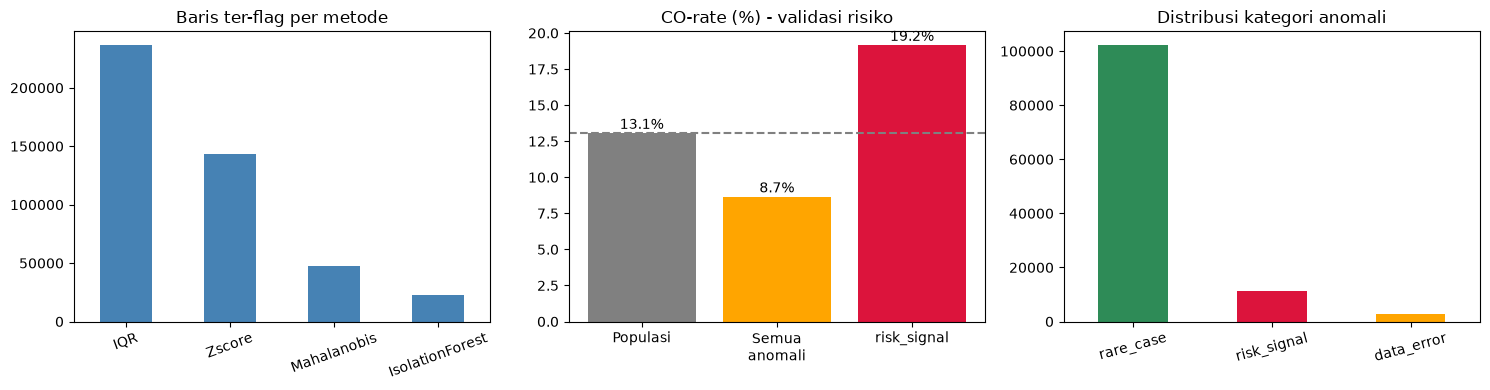

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
flags.sum().plot.bar(ax=ax[0], color='steelblue'); ax[0].set_title('Baris ter-flag per metode')
ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(['Populasi','Semua\nanomali','risk_signal'], [co_all, co_anom, co_highrisk],
          color=['grey','orange','crimson'])
ax[1].axhline(co_all, ls='--', c='grey'); ax[1].set_title('CO-rate (%) - validasi risiko')
for i,v in enumerate([co_all,co_anom,co_highrisk]): ax[1].text(i, v+0.3, f'{v:.1f}%', ha='center')
pd.Series(cls).value_counts().plot.bar(ax=ax[2], color=['seagreen','crimson','orange'])
ax[2].set_title('Distribusi kategori anomali'); ax[2].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.savefig('data/processed/phase4_anomaly_summary.png', dpi=120); plt.show()

In [14]:
out = df.iloc[idx_conf].copy()
out['loan_status']    = loan.iloc[idx_conf].values
out['n_methods']      = n_methods.values[idx_conf]
out['flag_IQR']       = iqr_flag[idx_conf]; out['flag_Zscore'] = z_flag[idx_conf]
out['flag_Maha']      = maha_flag[idx_conf]; out['flag_IsoForest'] = if_flag[idx_conf]
out['maha_dist2']     = md2[idx_conf].round(1)
out['risk_score']     = rs_conf.round(2)
out['classification'] = cls
out['outlier_type']   = otype
out.insert(0, 'orig_index', idx_conf)
out.sort_values('maha_dist2', ascending=False).to_csv('data/processed/phase4_anomalies.csv', index=False)
print(f'tersimpan: data/processed/phase4_anomalies.csv ({len(out):,} anomali terkonfirmasi)')

tersimpan: data/processed/phase4_anomalies.csv (116,225 anomali terkonfirmasi)


## 8. Investigasi record: contoh representatif tiap kategori
Ditampilkan langsung dari data (bukan angka yang ditulis manual) agar interpretasi terbukti.

In [15]:
show = ['orig_index','annual_inc','dti','fico_range_low','revol_util','all_util',
        'inq_last_6mths','loan_amnt','total_bc_limit','loan_status','n_methods',
        'maha_dist2','risk_score','outlier_type']
for cat in ['data_error','risk_signal','rare_case']:
    sub = out[out.classification==cat].sort_values('maha_dist2', ascending=False)
    print(f'\n===== {cat} (n={len(sub):,}) - 5 teratas =====')
    print(sub[show].head(5).to_string(index=False))


===== data_error (n=2,654) - 5 teratas =====
 orig_index  annual_inc  dti  fico_range_low  revol_util  all_util  inq_last_6mths  loan_amnt  total_bc_limit loan_status  n_methods  maha_dist2  risk_score outlier_type
     601124 110000000.0 0.01           695.0        83.5      84.0             0.0    30000.0         21300.0     Current          3   1020018.6        0.98        point
    1673117  61000000.0 0.01           690.0        35.1      35.0             1.0    10000.0         31800.0     Current          3    313530.2       -2.83        point
     539803  10999200.0 0.07           685.0        41.1      26.0             0.0     5000.0           700.0  Fully Paid          3     10146.2       -4.26        point
    1597133   9930475.0 0.19           670.0        65.4      61.0             1.0    16000.0         22500.0     Current          3      8156.2       -0.01        point
    1413796   9757200.0 0.15           665.0        12.2      56.0             1.0    14000.0         35

## 9. Interpretasi bisnis & temuan

**Ringkasan angka**, dari 271.143 kandidat (≥1 metode), **116.225 terkonfirmasi** (≥2 metode). Terbagi: `data_error` 2.654 · `risk_signal` 11.358 · `rare_case` 102.213.

### 9.1 data_error (2.654 · 0,12%) → masalah kualitas data
Nilai mustahil: `annual_inc` sampai $110 juta pada peminjam pinjaman <$40rb, dan baris `dti = 999` (sentinel tak-terhitung yang lolos ke data numerik). **Aksi**: kecualikan/koreksi sebelum modeling, bila dibiarkan, nilai-nilai ini menggeser mean & skala scaler dan mendistorsi seluruh model hilir.

### 9.2 risk_signal (11.358) → sinyal yang perlu dieskalasi
Dibentuk **independen** dari atribut tekanan kredit (dti/revol_util/all_util/inq tinggi), lalu terbukti: tingkat Charged Off/Default-nya **19,2% vs 13,1% populasi (lift ≈1,47×)**. Karena label ini tidak diturunkan dari outcome, angka 19,2% adalah validasi nyata, bukan tautologi. **Aksi**: jadikan kombinasi atribut ini aturan flag underwriting untuk review manual.

### 9.3 rare_case (102.213) → kasus valid tak biasa
Mayoritas anomali statistik justru peminjam **affluent / limit kartu besar** (mis. `total_bc_limit` > $1 juta) yang membayar lancar. **Aksi**: jangan tolak otomatis; kelompok ini bernilai bisnis tinggi meski outlier.

### 9.4 Temuan utama (kandidat finding laporan)
> Anomali statistik **bukan** proksi risiko kredit. Secara agregat, record anomali justru gagal bayar **lebih jarang** dari populasi (**8,7% vs 13,1%**), karena didominasi profil kaya. **Namun**, sub-populasi anomali yang high-stress secara atribut, diidentifikasi tanpa melihat outcome, gagal bayar **1,47× lebih sering** (19,2%).

Temuan ini memenuhi empat uji kualitas temuan: mengandung angka (8,7% / 13,1% / 19,2% / 1,47×), tidak terlihat dari tabulasi mentah, mengimplikasikan aksi bank spesifik (flag berbasis atribut, bukan berbasis status outlier), dan menghindari klaim kausal.

### Catatan tipe outlier
Terkonfirmasi didominasi **point** (115.978); **contextual** murni-multivariat hanya 43; **collective** (noise DBSCAN) 204. Artinya sebagian besar anomali dataset ini terlihat sudah pada satu dimensi, konsisten dengan dominasi ekor pada fitur finansial.

### Appendix D (kontribusi Phase 4)
Total kandidat sebelum corroboration: **271.143** · Anomali terkonfirmasi (≥2 metode): **116.225**.